In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from superstore_analysis.pipelines.training_pipeline import OrderPredictivePipeline
from superstore_analysis.datasets import DataLoader

In [2]:
data = DataLoader().from_gdrive()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        9994 non-null   object        
 1   Customer_ID     9994 non-null   object        
 2   Postal_Code     9994 non-null   int64         
 3   Product_ID      9994 non-null   object        
 4   Sales           9994 non-null   float64       
 5   Quantity        9994 non-null   int64         
 6   Discount        9994 non-null   float64       
 7   Profit          9994 non-null   float64       
 8   Category        9994 non-null   object        
 9   Sub-Category    9994 non-null   object        
 10  Product_Name    9994 non-null   object        
 11  Order_Date      9994 non-null   datetime64[ns]
 12  Ship_Date       9994 non-null   datetime64[ns]
 13  Ship_Mode       9994 non-null   object        
 14  Customer_Name   9994 non-null   object        
 15  Segm

In [3]:
trainer_pipe = OrderPredictivePipeline()
prepared_data = trainer_pipe.preprocessing(data)

2026-03-06 01:29:00.616 | INFO     | superstore_analysis.pipelines.feature_eng_pipeline:transform:15 - Start Feature Engineering...
2026-03-06 01:29:00.649 | INFO     | superstore_analysis.pipelines.training_pipeline:transform:252 - Creating features...
/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/training_pipeline.py:257: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_prep['Order_Diff'] = X_prep['Order_Count'].diff(1)
/Users/heykalsayid/Desktop/myown/superstore_analysis/src/superstore_analysis/pipelines/training_pipeline.py:258: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

[Pipeline]  (step 1 of 2) Processing feature_engineering, total=   0.0s
[Pipeline] .. (step 2 of 2) Processing feature_creation, total=   0.0s


In [4]:
trainer_pipe.print_cv_score_history_

No CV results found. Please run the train method first.


In [5]:
trainer_pipe.train()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 2/3] END min_samples_split=150, n_estimators=200;, score=-5.466 total time=   0.1s
[CV 1/3] END min_samples_split=150, n_estimators=200;, score=-4.817 total time=   0.1s
[CV 3/3] END min_samples_split=150, n_estimators=200;, score=-5.447 total time=   0.1s
[CV 1/3] END min_samples_split=150, n_estimators=250;, score=-4.823 total time=   0.2s
[CV 2/3] END min_samples_split=150, n_estimators=250;, score=-5.463 total time=   0.2s
[CV 3/3] END min_samples_split=150, n_estimators=250;, score=-5.448 total time=   0.1s
[CV 1/3] END min_samples_split=150, n_estimators=300;, score=-4.832 total time=   0.2s
[CV 2/3] END min_samples_split=150, n_estimators=300;, score=-5.466 total time=   0.2s
[CV 3/3] END min_samples_split=150, n_estimators=300;, score=-5.420 total time=   0.2s
[CV 1/3] END min_samples_split=150, n_estimators=350;, score=-4.786 total time=   0.2s
[CV 2/3] END min_samples_split=150, n_estimators=350;, score=-5.459 t

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'min_samples_split': [150, 200, ...], 'n_estimators': [200, 250, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the 

In [6]:
preds, eval_results = trainer_pipe.evaluate()


In [7]:
eval_results


{'model': RandomForestRegressor(min_samples_split=150, n_estimators=300),
 'model_name': 'RandomForestRegressor',
 'mae': 1.8780487804878048,
 'mae_test': 1.8843648208469055,
 'mape': 0.5873608365986702,
 'mape_test': 0.39786033586983244}

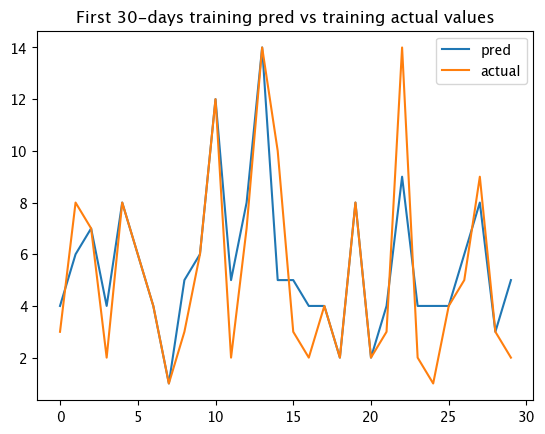

In [8]:
sns.lineplot(preds[0][:30], label='pred')
sns.lineplot(trainer_pipe.train_set[0].loc[:, trainer_pipe.original_target_col][:30].values, label='actual')
plt.title("First 30-days training pred vs training actual values")
plt.legend()
plt.show()

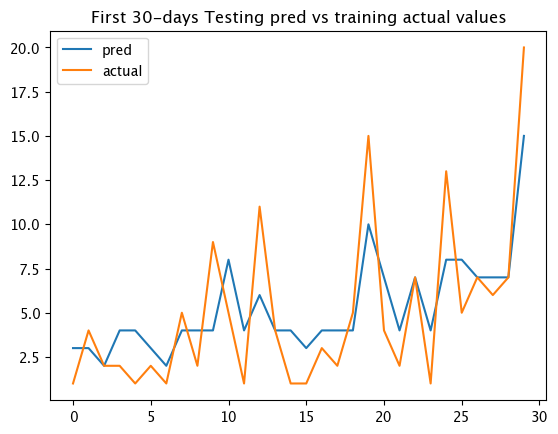

In [9]:
sns.lineplot(preds[1][:30], label='pred')
sns.lineplot(trainer_pipe.test_set[0].loc[:, trainer_pipe.original_target_col]
             [:30].values, label='actual')
plt.title("First 30-days Testing pred vs training actual values")
plt.legend()
plt.show()

Text(0.5, 1.0, 'The most influence feature for the tree to make a decision')

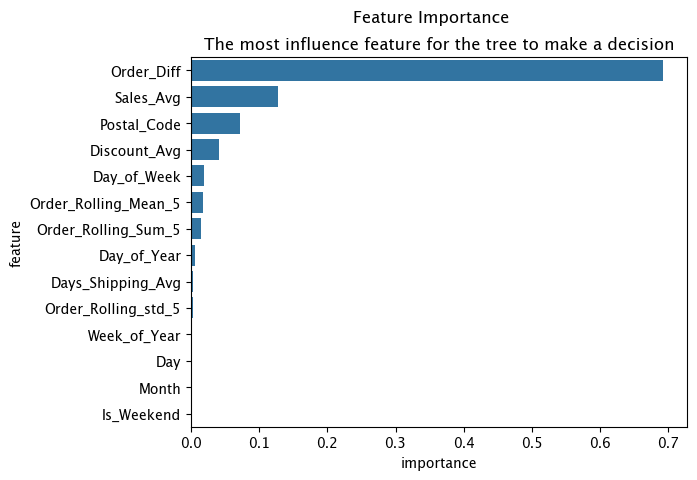

In [10]:
feat_importance_df = pd.DataFrame({
    'feature': trainer_pipe.train_set[0].columns.drop(trainer_pipe.original_target_col),
    'importance': eval_results['model'].feature_importances_
})

feat_importance_df = feat_importance_df.sort_values(
    by='importance', ascending=False)

sns.barplot(data=feat_importance_df, y='feature', x='importance')
plt.suptitle("Feature Importance")
plt.title("The most influence feature for the tree to make a decision")